# **Iris Flower Classification using Logistic Regression**

Step 1: Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Step 2: Load the Dataset

In [6]:
# Load Iris dataset
iris = load_iris()

# Create DataFrame
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add target column
iris_df['Species'] = iris.target

# Convert numeric labels into flower names
iris_df['Species'] = iris_df['Species'].map({
    0: 'Setosa',
    1: 'Versicolor',
    2: 'Virginica'
})

# Display first five rows
print(iris_df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  Species  
0  Setosa  
1  Setosa  
2  Setosa  
3  Setosa  
4  Setosa  


Step 3: Explore the Dataset

In [7]:
print(iris_df.shape)

print(iris_df.info())

print(iris_df.describe())

print(iris_df['Species'].value_counts())

(150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300

Step 4: Check Missing Values

In [8]:
print(iris_df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
dtype: int64


Step 5: Data Visualization

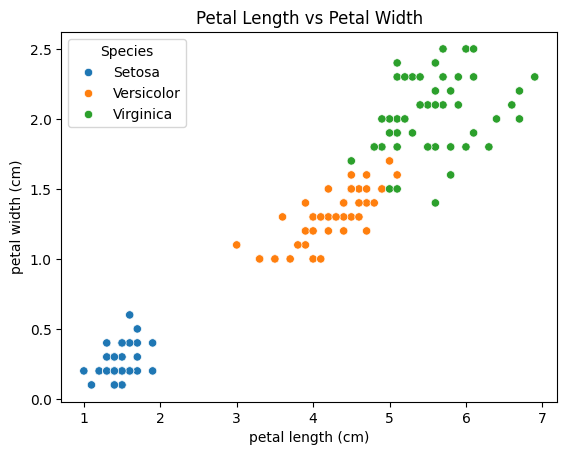

In [9]:
sns.scatterplot(
    data=iris_df,
    x='petal length (cm)',
    y='petal width (cm)',
    hue='Species'
)

plt.title("Petal Length vs Petal Width")
plt.show()

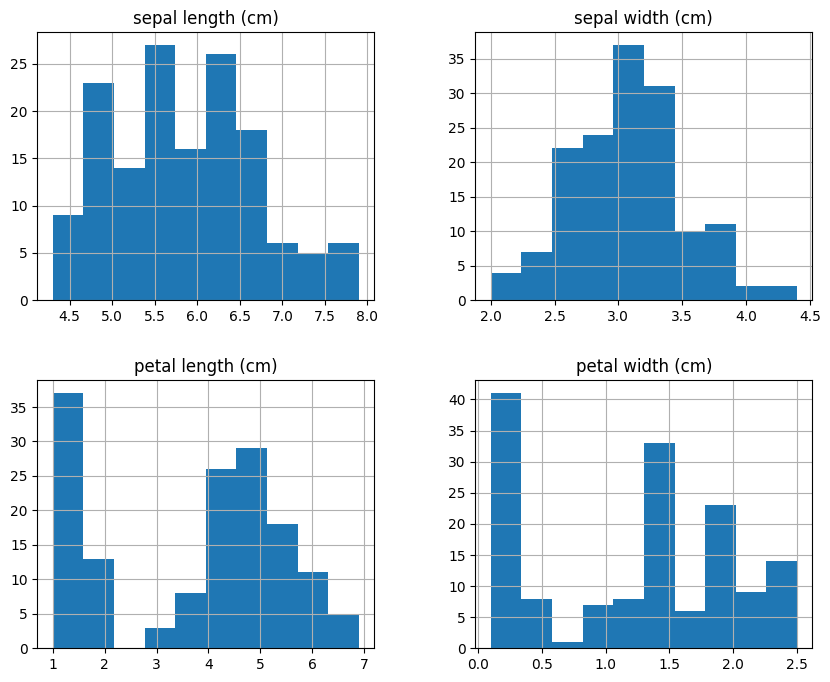

In [10]:
iris_df.hist(figsize=(10,8))
plt.show()

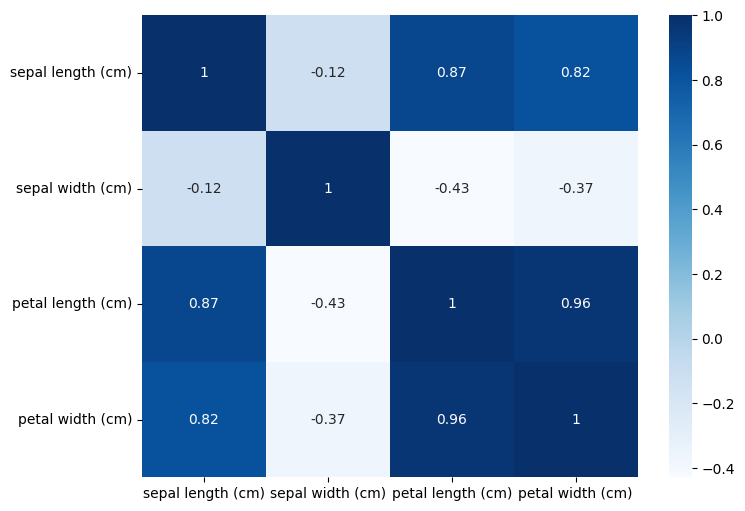

In [11]:
plt.figure(figsize=(8,6))

sns.heatmap(
    iris_df.drop('Species', axis=1).corr(),
    annot=True,
    cmap='Blues'
)

plt.show()

Step 6: Split Features and Target

In [12]:
X = iris.data
Y = iris.target

Step 7: Split Training and Testing Data

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

Step 8: Train Logistic Regression Model

In [14]:
model = LogisticRegression(max_iter=200)

model.fit(X_train, Y_train)

LogisticRegression(max_iter=200)

Step 9: Predict

In [15]:
predictions = model.predict(X_test)

Step 10: Model Evaluation

In [16]:
accuracy = accuracy_score(Y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [17]:
print(classification_report(
    Y_test,
    predictions,
    target_names=iris.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [18]:
cm = confusion_matrix(Y_test, predictions)

print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


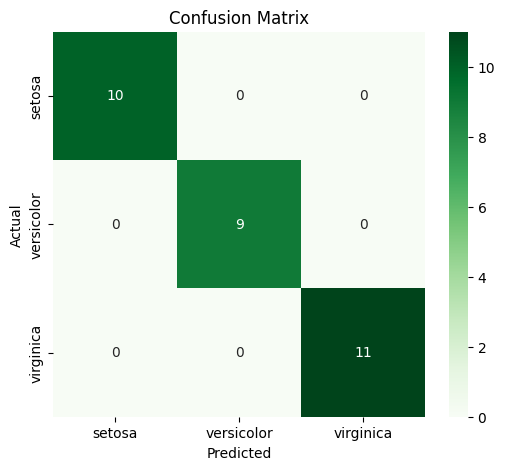

In [19]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Step 11: Predict a New Flower

In [20]:
sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(sample)

print("Predicted Species:", iris.target_names[prediction][0])

Predicted Species: setosa
